In [4]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

# HDFC Bank Ltd. Analysis

In [6]:
def get_data(start_date, end_date):
    ticker = "HDFCBANK.NS"
    
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d"
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    return data

In [8]:
data = get_data("2017-01-01", "2025-12-31")

[*********************100%***********************]  1 of 1 completed


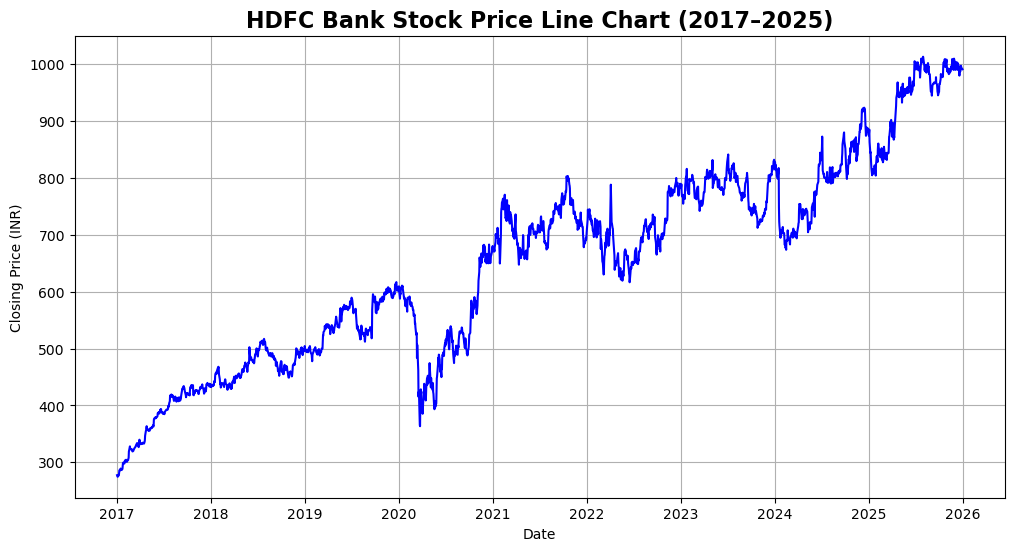

In [10]:
# Line chart 
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], color='blue')
plt.title("HDFC Bank Stock Price Line Chart (2017–2025)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid()
plt.show()

In [12]:
# The chart shows an overall upward trend in stock prices, indicating long-term growth.
# Some fluctuations are present, showing short-term market volatility.
# A noticeable drop around 2020 is followed by a strong recovery.

### Trend Analysis Using Moving Averages

In [14]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean() 
data

Price,Close,High,Low,Open,Volume,MA20,MA50
Date,,,,,,,
2017-01-02,277.461823,280.474941,276.291359,280.324279,3708656,NaN,NaN
2017-01-03,275.793030,278.585942,274.831144,278.319419,3847500,NaN,NaN
2017-01-04,274.773224,276.279783,274.379212,275.781454,6967120,NaN,NaN
2017-01-05,274.935455,276.859227,274.216948,275.584446,6776384,NaN,NaN
2017-01-06,276.662201,277.763148,275.398992,275.839377,5525260,NaN,NaN
...,...,...,...,...,...,...,...
2025-12-23,996.599976,998.900024,987.700012,990.500000,17927849,996.479993,994.782997
2025-12-24,997.200012,999.400024,993.000000,993.000000,13699996,996.144992,995.186997
2025-12-26,992.099976,997.200012,987.700012,996.000000,9360853,995.274991,995.485996


In [16]:
data['Trend'] = 'Downtrend'
data.loc[data['MA20'] > data['MA50'], 'Trend'] = 'Uptrend'
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend
Date,,,,,,,,
2017-01-02,277.461823,280.474941,276.291359,280.324279,3708656,NaN,NaN,Downtrend
2017-01-03,275.793030,278.585942,274.831144,278.319419,3847500,NaN,NaN,Downtrend
2017-01-04,274.773224,276.279783,274.379212,275.781454,6967120,NaN,NaN,Downtrend
2017-01-05,274.935455,276.859227,274.216948,275.584446,6776384,NaN,NaN,Downtrend
2017-01-06,276.662201,277.763148,275.398992,275.839377,5525260,NaN,NaN,Downtrend
...,...,...,...,...,...,...,...,...
2025-12-23,996.599976,998.900024,987.700012,990.500000,17927849,996.479993,994.782997,Uptrend
2025-12-24,997.200012,999.400024,993.000000,993.000000,13699996,996.144992,995.186997,Uptrend
2025-12-26,992.099976,997.200012,987.700012,996.000000,9360853,995.274991,995.485996,Downtrend


### Daily Returns

In [18]:
data['Daily Return'] = data['Close'].pct_change()
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend,Daily Return
Date,,,,,,,,,
2017-01-02,277.461823,280.474941,276.291359,280.324279,3708656,NaN,NaN,Downtrend,NaN
2017-01-03,275.793030,278.585942,274.831144,278.319419,3847500,NaN,NaN,Downtrend,-0.006014
2017-01-04,274.773224,276.279783,274.379212,275.781454,6967120,NaN,NaN,Downtrend,-0.003698
2017-01-05,274.935455,276.859227,274.216948,275.584446,6776384,NaN,NaN,Downtrend,0.000590
2017-01-06,276.662201,277.763148,275.398992,275.839377,5525260,NaN,NaN,Downtrend,0.006281
...,...,...,...,...,...,...,...,...,...
2025-12-23,996.599976,998.900024,987.700012,990.500000,17927849,996.479993,994.782997,Uptrend,0.009011
2025-12-24,997.200012,999.400024,993.000000,993.000000,13699996,996.144992,995.186997,Uptrend,0.000602
2025-12-26,992.099976,997.200012,987.700012,996.000000,9360853,995.274991,995.485996,Downtrend,-0.005114


### Handling of missing values

In [20]:
# Replace first NaN in Daily Return
data['Daily Return'].fillna(0)

# Forward fill remaining missing values
data.ffill(inplace=True)

# Remove any remaining initial NaN rows (from MA20, MA50, etc.)
data.dropna(inplace=True)

# Final check
print(data.isnull().sum())

Price
Close           0
High            0
Low             0
Open            0
Volume          0
MA20            0
MA50            0
Trend           0
Daily Return    0
dtype: int64


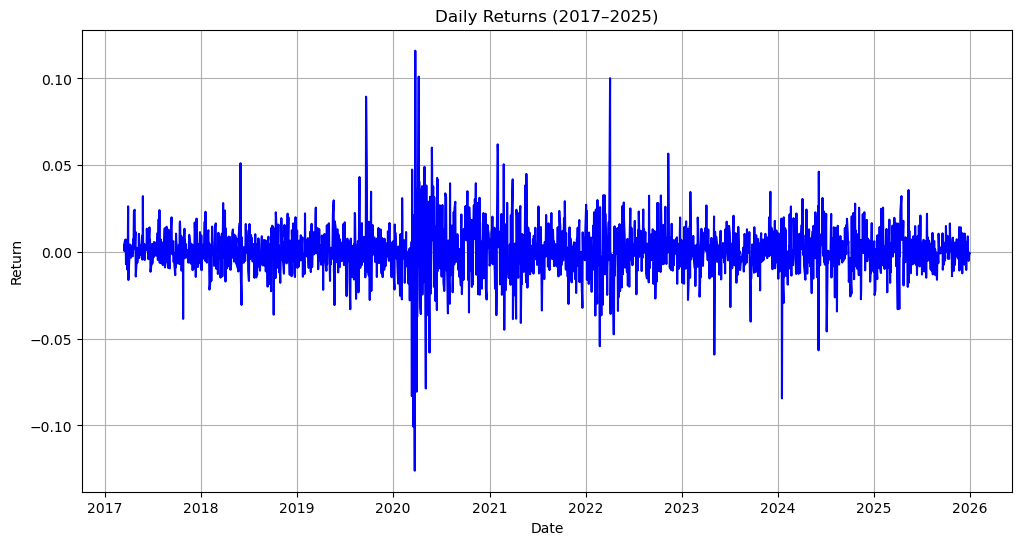

In [22]:
# Line chart (Daily Returns Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'], color='blue')
plt.title("Daily Returns (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid()
plt.show()

In [24]:
# The daily returns are mostly centered around zero, indicating stable average performance over time.
# However, the presence of sharp spikes and drops shows short-term volatility and occasional sudden market movements.

### Daily Volatility

In [26]:
daily_vol = data['Daily Return'].std()
print(f"Daily Volatility: {daily_vol*100:.2f}%")

Daily Volatility: 1.46%


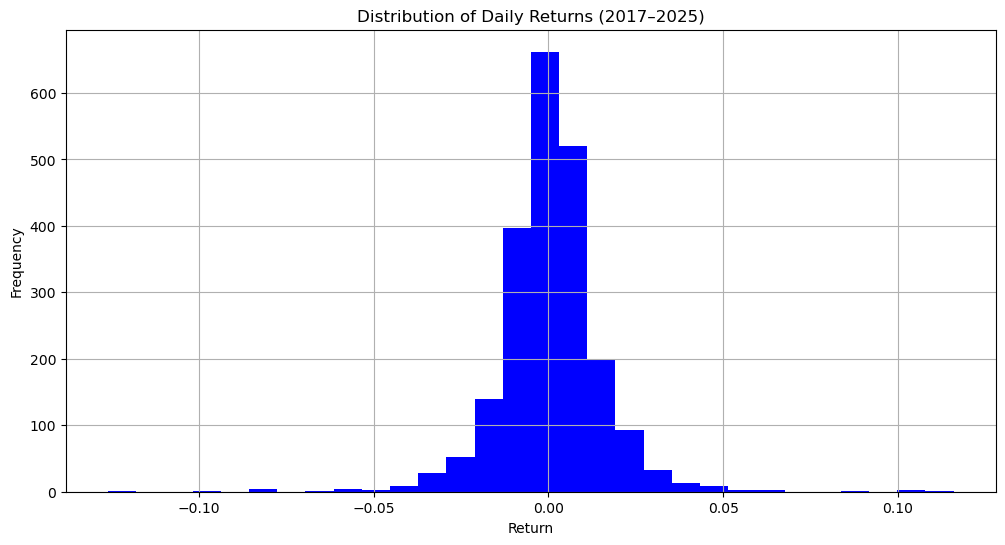

In [28]:
# Histogram (Distribution of Daily Returns)
plt.figure(figsize=(12,6))
plt.hist(data['Daily Return'].dropna(), bins=30, color='blue')
plt.title("Distribution of Daily Returns (2017–2025)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [30]:
# The histogram shows that most daily returns are concentrated around zero, indicating stable average performance.
# However, the spread of the data and presence of extreme values suggest periods of higher volatility in the stock.

### Annualized Volatility

In [32]:
annual_vol = daily_vol * np.sqrt(252)
print(f"Annualized Volatility: {annual_vol*100:.2f}%")

Annualized Volatility: 23.26%


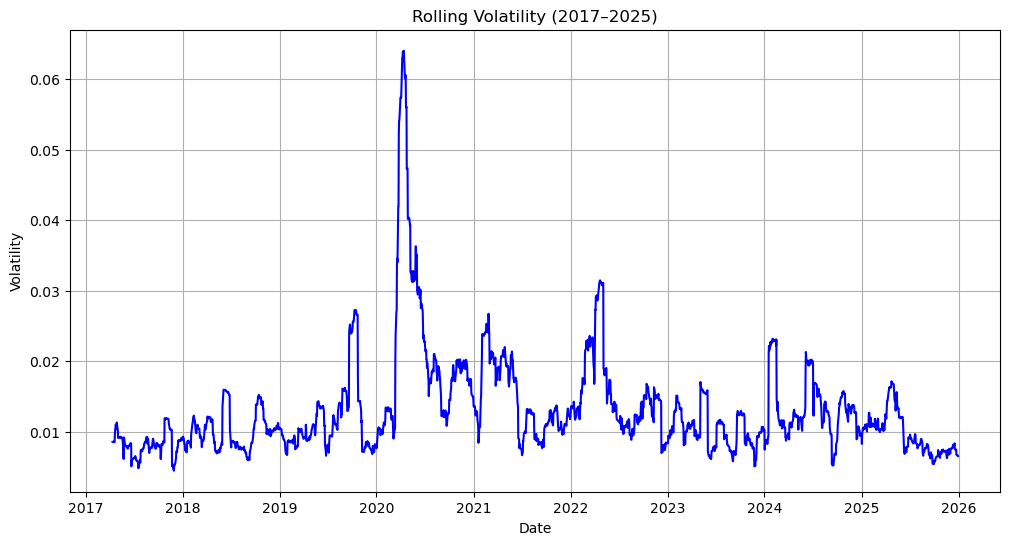

In [34]:
data['Rolling Volatility'] = data['Daily Return'].rolling(20).std()

# Line chart (Rolling Volatility Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Rolling Volatility'], color='blue')
plt.title("Rolling Volatility (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

In [36]:
# The rolling volatility plot shows that volatility is mostly low and stable over time.
# However, there are sharp spikes (especially around 2020), indicating periods of higher risk and market uncertainty.
# After COVID, volatility decreases but remains slightly higher, with more frequent fluctuations indicating moderate instability.

### 📊 Conclusion

### HDFC Bank stock shows a steady growth trend with moderate fluctuations over time.
### - Volatility suggests relatively low to moderate market risk compared to peers.
### - Moving averages indicate a mixed trend with recent signs of a downward direction.
### - Daily returns indicate consistent performance with occasional short-term variations.